Going to try with matplot lib

I used chatgpt to help me generate some of this initial code

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

Read in dataframes, and then make a list of dataframes so I can run through them all

In [2]:
df_2005 = pd.read_csv('DC-migration-2005.csv')
df_2009 = pd.read_csv('DC-migration-2009.csv')
df_2013 = pd.read_csv('DC-migration-2013.csv')
df_2017 = pd.read_csv('DC-migration-2017.csv')
df_2021 = pd.read_csv('DC-migration-2021.csv')



Drop the initial columns that were carried over from the indexes and messing up this data.

In [3]:
df_2005 = df_2005.drop(columns=["Unnamed: 0"])
df_2009 = df_2009.drop(columns=["Unnamed: 0"])
df_2013 = df_2013.drop(columns=["Unnamed: 0"])
df_2017 = df_2017.drop(columns=["Unnamed: 0"])
df_2021 = df_2021.drop(columns=["Unnamed: 0"])

In [4]:
dfs = [df_2005, df_2009, df_2013, df_2017, df_2021]

In [5]:
df_2005.tail()

,state,pop_migrated,MOE +/-,state_population,pop_migrated_upper,pop_migrated_lower,migrated_adjusted,migrated_adjusted_upper,migrated_adjusted_lower,moe_adjusted,winning_party,winner_percent_of_votes
43,Vermont,27,46,643077,73,-19,0.000042,0.000114,-0.000030,0.000072,DEMOCRAT,0.589375
44,Washington,443,354,7705281,797,89,0.000057,0.000103,0.000012,0.000046,DEMOCRAT,0.528211
45,West Virginia,389,376,1793716,765,13,0.000217,0.000426,0.000007,0.000210,REPUBLICAN,0.560707
46,Wisconsin,49,82,5893718,131,-33,0.000008,0.000022,-0.000006,0.000014,DEMOCRAT,0.496997
47,Wyoming,0,286,576851,286,-286,0.000000,0.000496,-0.000496,0.000496,REPUBLICAN,0.687396


Add in a state year column so in order to be able to loop through the dataframes


In [6]:
df_2005['year'] = 2005
df_2009['year'] = 2009
df_2013['year'] = 2013
df_2017['year'] = 2017
df_2021['year'] = 2021


Ok, multiplying by 100,000 to make the migrated_adjusted and moe_adjusted more readable 

In [7]:
for df in dfs:
    df['migrated_adjusted'] = df['migrated_adjusted'] * 100000
    df['moe_adjusted'] = df['moe_adjusted']* 100000

Some code to help me adjust the colors based on party, and strength of color to represent how red or blue the state 

In [8]:
# this converts into RGB numbers between 0 and 

def adjust_color(color, factor):
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(np.clip(rgb * factor, 0, 1))

BASE_COLORS = {
    "REPUBLICAN": "#d62728",
    "DEMOCRAT": "#1f77b4"
}

Make sure all the values I need are numeric.

In [9]:
for df in dfs:

    df["migrated_adjusted"] = pd.to_numeric(df["migrated_adjusted"])
    df["moe_adjusted"] = pd.to_numeric(df["moe_adjusted"])
    df["winner_percent_of_votes"] = pd.to_numeric(df["winner_percent_of_votes"])


   

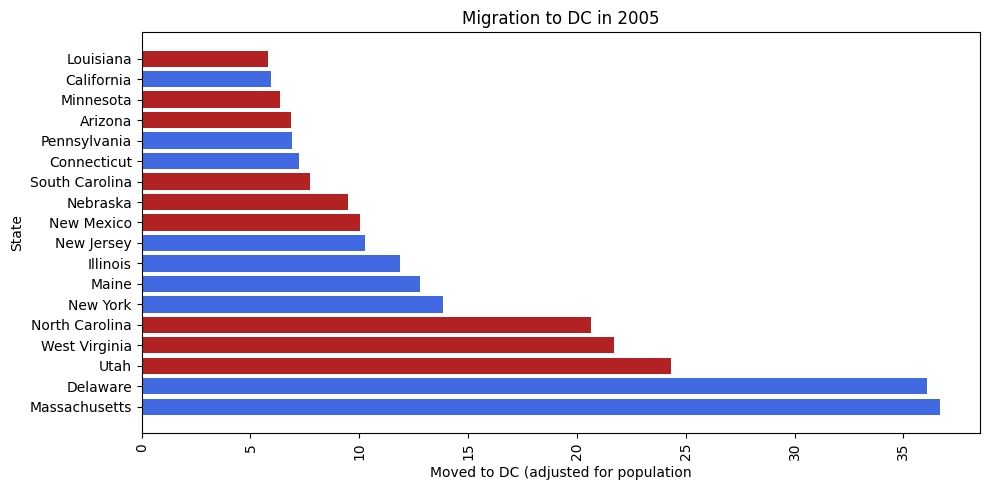

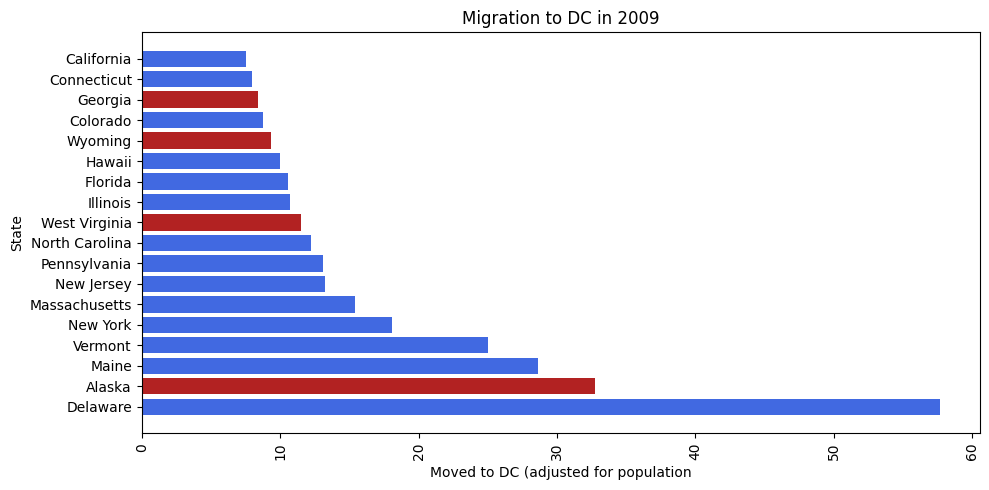

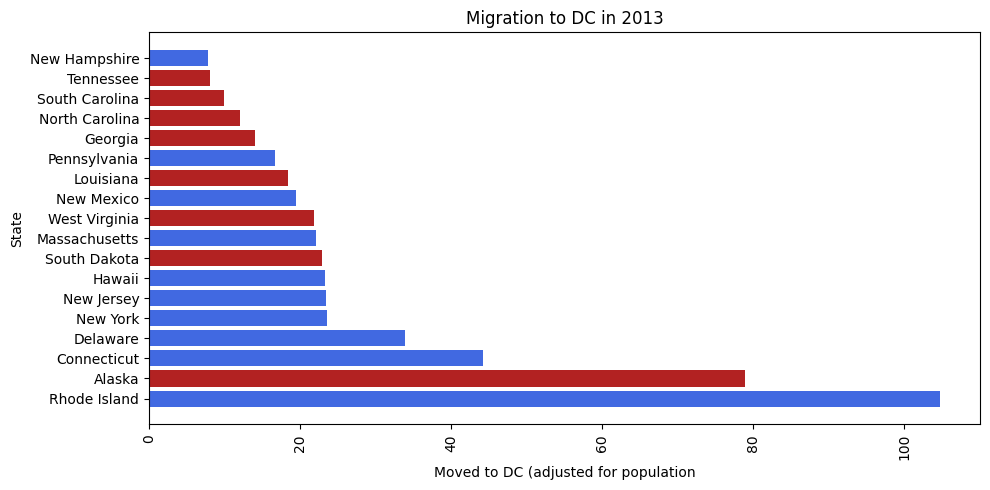

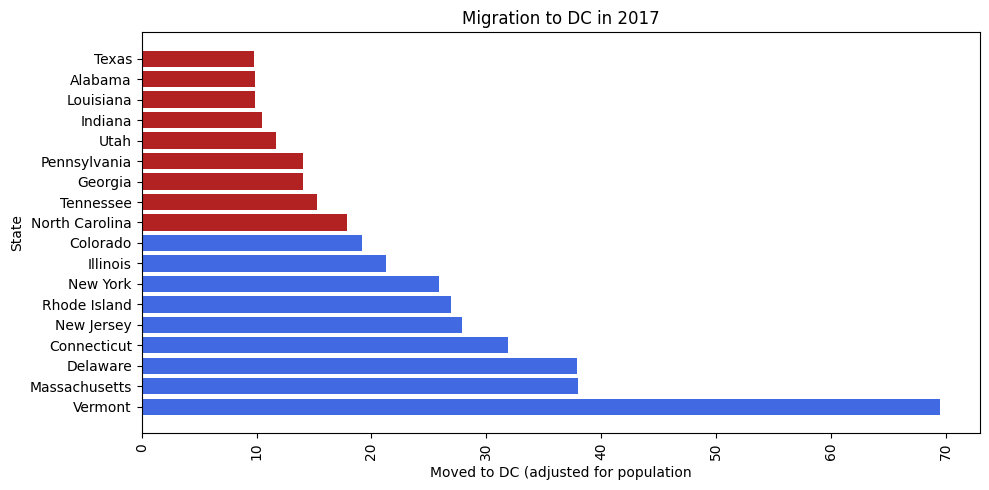

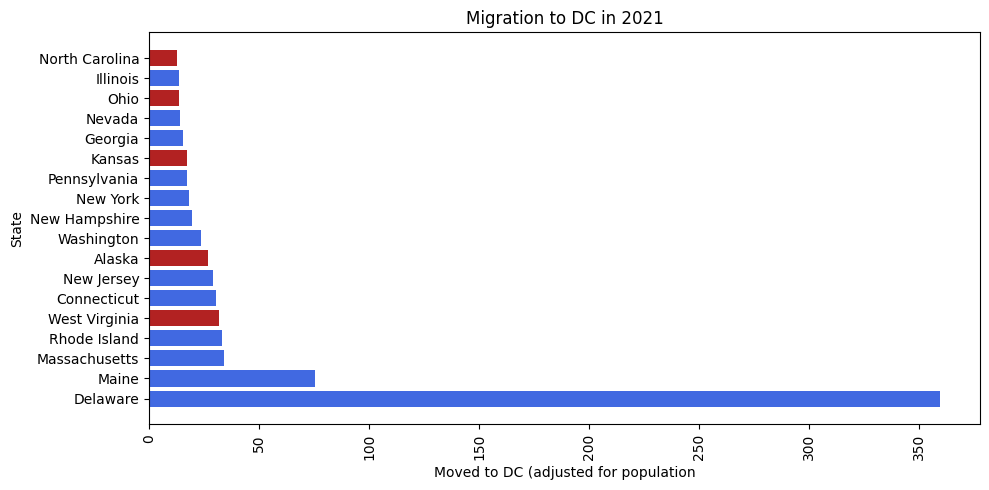

In [10]:
import matplotlib.pyplot as plt

for df in dfs:

    # Keep only the 8 states with the largest migration values
    df = df.nlargest(18, "migrated_adjusted")
    df.reset_index(drop=True, inplace=True)

    party_colors = {
    "REPUBLICAN": "firebrick",
    "DEMOCRAT": "royalblue"
    }

    colors = [party_colors.get(party, "gray") for party in df["winning_party"]]

    plt.figure(figsize=(10, 5))

    plt.barh(
        df["state"],                   # Labels on the x-axis
        df["migrated_adjusted"],       # Height of each bar
        # xerr=df["moe_adjusted"],       # Error bars (+/-)
        # capsize=3                      # Small horizontal caps on error bars
        color=colors

    )

    # Add labels and a title
    plt.title(f'Migration to DC in {df.loc[0, 'year']}')
    plt.xlabel("Moved to DC (adjusted for population)")
    plt.ylabel("State")

    plt.xticks(rotation=90) # Rotate state names so they don't overlap

    plt.tight_layout()  # Automatically adjust spacing

    plt.show() # Display the chart
